# Fine-Tuning de LLM para Clasificación Multiclase
## Dataset: `SetFit/amazon_reviews_multi_es` | Modelo: `xlm-roberta-base` + LoRA

**Cambios principales respecto al notebook base:**

| Aspecto | Notebook base | Este notebook |
|---------|--------------|---------------|
| Modelo base | BETO (solo español) | XLM-RoBERTa base (100 idiomas) |
| Training set | 50k de 200k | 200k completos |
| LoRA rank | r=16 | r=8 (menos overfitting) |
| Módulos LoRA | query, value | query, value, key, dense |
| Learning rate | 2e-4 | 2e-5 (estándar fine-tuning) |
| Batch size | 8 | 32 (aprovecha 3090 24GB) |
| Scheduler | linear | cosine |
| Regularización | weight_decay | + label_smoothing=0.1 |
| Anti-overfitting | — | EarlyStoppingCallback(patience=3) |
| Precision | fp32 | fp16 (mixed precision) |


## 1. Instalación de dependencias

In [3]:
# Versiones compatibles con CUDA 11.8 (RTX 3090)
!pip install transformers==4.38.2
!pip install accelerate==0.27.2
!pip install peft==0.9.0
!pip install datasets scikit-learn matplotlib seaborn
# Descomentar si PyTorch no está instalado:
# !pip install torch==2.0.0+cu118 torchvision==0.15.1+cu118 torchaudio==2.0.1 \
#     --index-url https://download.pytorch.org/whl/cu118


   ---------------------------------------- 0.0/8.5 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.5 MB 14.4 MB/s eta 0:00:01
   ---------------------------------------- 8.5/8.5 MB 25.3 MB/s  0:00:00
   ---------------------------------------- 0.0/566.4 kB ? eta -:--:--
   ---------------------------------------- 566.4/566.4 kB 20.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 31.1 MB/s  0:00:00

  Attempting uninstall: huggingface-hub

    Found existing installation: huggingface_hub 1.7.1

    Uninstalling huggingface_hub-1.7.1:

      Successfully uninstalled huggingface_hub-1.7.1

   ---------------------------------------- 0/3 [huggingface-hub]
   ---------------------------------------- 0/3 [huggingface-hub]
   ---------------------------------------- 0/3 [huggingface-hub]
   ---------------------------------------- 0/3 [huggingface-hub]
   ----------------------------

## 2. Verificar GPU y VRAM disponible

In [1]:
import torch

print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    free  = torch.cuda.mem_get_info()[0] / 1e9
    print(f'VRAM total: {total:.1f} GB')
    print(f'VRAM libre: {free:.1f} GB')


CUDA disponible: True
GPU: NVIDIA GeForce RTX 3090
VRAM total: 25.8 GB
VRAM libre: 24.4 GB


## 3. Imports y semilla de reproducibilidad

In [4]:
import sys

!{sys.executable} -m pip install -q \
    transformers==4.38.2 \
    accelerate==0.27.2 \
    peft==0.9.0 \
    datasets \
    scikit-learn \
    matplotlib \
    seaborn

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
import torch
import numpy as np
import random
import collections
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Semilla global para reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    classification_report,
    confusion_matrix,
)

print('Imports OK')


C:\Users\AaronMCC\miniconda3\envs\clas_Rest-Mex2025\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.
0it [00:00, ?it/s]
W0331 12:15:04.550000 39900 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Imports OK


## 4. Carga y exploración del dataset

El corpus MARC (Keung et al., EMNLP 2020) tiene 200k/5k/5k ejemplos en train/dev/test para español, balanceados entre 5 clases (1–5 estrellas). El notebook base solo usaba 50k/200k — aquí se usa el training set completo.

> **Nota sobre la dificultad:** la clasificación de 5 estrellas es inherentemente difícil porque las clases adyacentes (2★/3★ y 3★/4★) son ambiguas incluso para anotadores humanos. F1 Macro entre 0.63–0.70 es competitivo con la literatura.

In [6]:
dataset = load_dataset('SetFit/amazon_reviews_multi_es')

print(dataset)
print('\nColumnas:', dataset['train'].column_names)

print('\nDistribución de clases en train:')
counter = collections.Counter(dataset['train']['label'])
for clase, n in sorted(counter.items()):
    print(f'  Clase {clase+1}★: {n:,} ejemplos ({n/len(dataset["train"])*100:.1f}%)')

print('\nEjemplo de entrada:')
print(dataset['train'][0])


C:\Users\AaronMCC\miniconda3\envs\clas_Rest-Mex2025\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\AaronMCC\.cache\huggingface\hub\datasets--SetFit--amazon_reviews_multi_es. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Repo card metadata block was not found. Setting CardData to empty.
Generating tes

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})

Columnas: ['id', 'text', 'label', 'label_text']

Distribución de clases en train:
  Clase 1★: 40,000 ejemplos (20.0%)
  Clase 2★: 40,000 ejemplos (20.0%)
  Clase 3★: 40,000 ejemplos (20.0%)
  Clase 4★: 40,000 ejemplos (20.0%)
  Clase 5★: 40,000 ejemplos (20.0%)

Ejemplo de entrada:
{'id': 'es_0491108', 'text': 'Nada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante', 'label': 0, 'label_text': '0'}


## 5. Tokenizador

`xlm-roberta-base` tiene un vocabulario de 250k tokens (vs. ~31k de BETO), lo que le permite representar mejor el español coloquial y las mezclas lingüísticas típicas de reseñas de Amazon.

In [10]:
MODEL_NAME = 'xlm-roberta-base'

tokenizador = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizador cargado:', MODEL_NAME)
print('Vocab size:', tokenizador.vocab_size)

# Verificar longitud promedio de las reseñas
sample_texts = dataset['train']['text'][:1000]
lengths = [len(tokenizador(t)['input_ids']) for t in sample_texts]
print(f'\nLongitud de tokens (muestra 1k):  media={np.mean(lengths):.0f}, p90={np.percentile(lengths,90):.0f}, max={max(lengths)}')
print('-> max_length=256 cubre la gran mayoría de reseñas')


Tokenizador cargado: xlm-roberta-base
Vocab size: 250002

Longitud de tokens (muestra 1k):  media=40, p90=73, max=265
-> max_length=256 cubre la gran mayoría de reseñas


In [12]:
tokenizador

XLMRobertaTokenizerFast(name_or_path='xlm-roberta-base', vocab_size=250002, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	250001: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}

## 6. Tokenización del dataset completo

Se usa padding dinámico (`DataCollatorWithPadding`) en lugar de padding estático, que es más eficiente: cada batch se rellena solo hasta la longitud máxima del batch, no hasta `max_length` global.

In [16]:
def tokenizar(ejemplo, tok):
    return tok(
        ejemplo['text'],
        truncation=True,
        max_length=256,
        # Sin padding aquí; el DataCollator lo aplica dinámicamente
    )

datos_tokenizados = dataset.map(
    tokenizar,
    batched=True,
    num_proc=1,
    fn_kwargs={"tok": tokenizador},
    desc='Tokenizando',
)
datos_tokenizados = datos_tokenizados.remove_columns(['text', 'label_text'])
datos_tokenizados.set_format('torch')

print('Tokenización completa')
print(f'  Train: {len(datos_tokenizados["train"]):,} ejemplos')
print(f'  Val:   {len(datos_tokenizados["validation"]):,} ejemplos')
print(f'  Test:  {len(datos_tokenizados["test"]):,} ejemplos')


Tokenizando (num_proc=1): 100%|████████████████████████████████████████████| 5000/5000 [00:12<00:00, 414.05 examples/s]

Tokenización completa
  Train: 200,000 ejemplos
  Val:   5,000 ejemplos
  Test:  5,000 ejemplos


## 7. Modelo + configuración LoRA

**Justificación de cambios en LoRA:**

- `r=8` (vs. `r=16` en el base): el rank controla cuántos parámetros nuevos se introducen. Un rank menor reduce la capacidad del adaptador y actúa como regularizador, mitigando el overfitting observado en el notebook base.

- `target_modules` ampliado: incluir `key` y `dense` además de `query`/`value` cubre más transformaciones de la atención y las capas feed-forward, mejorando la adaptación sin aumentar demasiado los parámetros.

- `lora_alpha=16`: se mantiene el ratio `alpha/r = 2`, que escala apropiadamente la magnitud de las actualizaciones LoRA.

In [17]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizador)

modelo = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    ignore_mismatched_sizes=True,
)

lora_config = LoraConfig(
    r=8,                     
    lora_alpha=16,           
    target_modules=[
        'query',
        'value',
        'key',               
        'dense',             
    ],
    lora_dropout=0.1,
    bias='none',
    task_type=TaskType.SEQ_CLS,
)

modelo = get_peft_model(modelo, lora_config)
modelo.print_trainable_parameters()


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,933,829 || all params: 279,993,610 || trainable%: 0.6906689763384243


## 8. Función de métricas Macro

El promedio **Macro** calcula cada métrica por clase y luego promedia sin ponderar, lo que trata a todas las clases por igual. Como el dataset está balanceado (20% cada clase), Macro y Weighted darán resultados similares, pero Macro es la métrica requerida.

In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro'
    )
    acc = accuracy_score(labels, preds)

    return {
        'accuracy':        acc,
        'precision_macro': precision,
        'recall_macro':    recall,
        'f1_macro':        f1,
    }


## 9. Argumentos de entrenamiento

**Decisiones de hiperparámetros:**

- `learning_rate=2e-5`: el rango estándar para fine-tuning de transformers es 1e-5 a 5e-5. El notebook base usaba 2e-4, que es excesivo y causa catastrophic forgetting.

- `batch_size=32`: con XLM-RoBERTa-base + LoRA + fp16, el uso de VRAM es ~10–12 GB, dentro de los 24 GB de la RTX 3090.

- `label_smoothing_factor=0.1`: en lugar de usar one-hot duras (0/1), suaviza las etiquetas a (0.02/0.9). Ayuda con clases ambiguas como 3★ que podrían ser 2★ o 4★.

- `lr_scheduler_type='cosine'`: decae suavemente el LR en lugar de linealmente, lo que mejora la convergencia final.

- `fp16=True`: entrenamiento en precisión mixta, reduce VRAM a la mitad y acelera ~1.5–2x en GPUs Ampere.

In [19]:
training_args = TrainingArguments(
    output_dir='modelo-xlmr-lora',

    # Evaluación y guardado
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1_macro',
    greater_is_better=True,

    # Batch y épocas
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=10,          # EarlyStopping detiene antes si es necesario

    # Optimizador y LR
    optim='adamw_torch',
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.06,
    lr_scheduler_type='cosine',

    # Regularización
    label_smoothing_factor=0.1,

    # Hardware
    fp16=True,
    dataloader_num_workers=4,
    dataloader_pin_memory=True,

    # Logging
    logging_strategy='epoch',
    save_total_limit=2,
    report_to='none',
)

print('TrainingArguments configurados OK')


TrainingArguments configurados OK


## 10. Entrenamiento

`EarlyStoppingCallback(early_stopping_patience=3)` detiene el entrenamiento si el F1 Macro en validación no mejora durante 3 épocas consecutivas. Esto elimina el overfitting automáticamente sin necesidad de ajustar manualmente `num_train_epochs`.

In [20]:
trainer = Trainer(
    model=modelo,
    args=training_args,
    train_dataset=datos_tokenizados['train'],       # 200k completos
    eval_dataset=datos_tokenizados['validation'],
    data_collator=data_collator,
    tokenizer=tokenizador,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=3),
    ],
)

print('Iniciando entrenamiento...')
print(f'Ejemplos de entrenamiento: {len(datos_tokenizados["train"]):,}')
print(f'Batch size efectivo:       {training_args.per_device_train_batch_size}')
print(f'Epocas maximas:            {training_args.num_train_epochs}')
print(f'LR:                        {training_args.learning_rate}')
print()
trainer.train()


C:\Users\AaronMCC\miniconda3\envs\clas_Rest-Mex2025\lib\site-packages\accelerate\accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Iniciando entrenamiento...
Ejemplos de entrenamiento: 200,000
Batch size efectivo:       32
Epocas maximas:            10
LR:                        2e-05



Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.287800,1.158829,0.554400,0.547988,0.554400,0.549687
2,1.148400,1.136592,0.563000,0.559965,0.563000,0.559407
3,1.131100,1.131481,0.569400,0.569486,0.569400,0.562718
4,1.119700,1.118318,0.572400,0.564118,0.572400,0.566061
5,1.111000,1.116116,0.578200,0.570241,0.578200,0.571911
6,1.104200,1.112274,0.576600,0.578041,0.576600,0.577238
7,1.100400,1.109789,0.579400,0.575908,0.579400,0.577398
8,1.096400,1.106874,0.582200,0.580277,0.582200,0.579399
9,1.093400,1.106627,0.581600,0.577680,0.581600,0.578464
10,1.092700,1.107445,0.582800,0.578870,0.582800,0.579253


C:\Users\AaronMCC\miniconda3\envs\clas_Rest-Mex2025\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\AaronMCC\miniconda3\envs\clas_Rest-Mex2025\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\AaronMCC\miniconda3\envs\clas_Rest-Mex2025\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
IOPub message rate exceeded.
The Jupyter server will temporar

TrainOutput(global_step=62500, training_loss=1.12851759375, metrics={'train_runtime': 14238.7593, 'train_samples_per_second': 140.462, 'train_steps_per_second': 4.389, 'total_flos': 1.4823646122117926e+17, 'train_loss': 1.12851759375, 'epoch': 10.0})

## 11. Evaluación en el conjunto de test

Se carga el mejor checkpoint (elegido por F1 Macro en validación) y se evalúa sobre el test set completo (5,000 ejemplos).

In [21]:
best_path = trainer.state.best_model_checkpoint
print(f'Mejor checkpoint: {best_path}')

# Reconstruir el modelo desde el checkpoint
modelo_base_eval = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=5, ignore_mismatched_sizes=True
)
modelo_mejor = PeftModel.from_pretrained(modelo_base_eval, best_path)

eval_args = TrainingArguments(
    output_dir='eval_tmp',
    per_device_eval_batch_size=64,
    fp16=True,
    report_to='none',
)

trainer_eval = Trainer(
    model=modelo_mejor,
    args=eval_args,
    tokenizer=tokenizador,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

resultados = trainer_eval.evaluate(datos_tokenizados['test'])

print('\n' + '='*45)
print('       RESULTADOS EN TEST SET')
print('='*45)
print(f'  Accuracy:        {resultados["eval_accuracy"]:.4f}')
print(f'  Precision Macro: {resultados["eval_precision_macro"]:.4f}')
print(f'  Recall Macro:    {resultados["eval_recall_macro"]:.4f}')
print(f'  F1 Macro:        {resultados["eval_f1_macro"]:.4f}')
print('='*45)


Mejor checkpoint: modelo-xlmr-lora\checkpoint-50000


C:\Users\AaronMCC\miniconda3\envs\clas_Rest-Mex2025\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\AaronMCC\miniconda3\envs\clas_Rest-Mex2025\lib\site-packages\accelerate\accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)



       RESULTADOS EN TEST SET
  Accuracy:        0.5890
  Precision Macro: 0.5856
  Recall Macro:    0.5890
  F1 Macro:        0.5861


## 12. Reporte por clase y matriz de confusión

La matriz de confusión permite identificar si los errores son aleatorios o sistemáticos (e.g., el modelo confunde mayormente clases adyacentes, lo cual es esperable en este dataset).

CLASSIFICATION REPORT (clases: 1 a 5 estrellas)
              precision    recall  f1-score   support

  1 estrella       0.71      0.71      0.71      1000
 2 estrellas       0.51      0.54      0.52      1000
 3 estrellas       0.51      0.47      0.49      1000
 4 estrellas       0.54      0.47      0.50      1000
 5 estrellas       0.66      0.75      0.71      1000

    accuracy                           0.59      5000
   macro avg       0.59      0.59      0.59      5000
weighted avg       0.59      0.59      0.59      5000



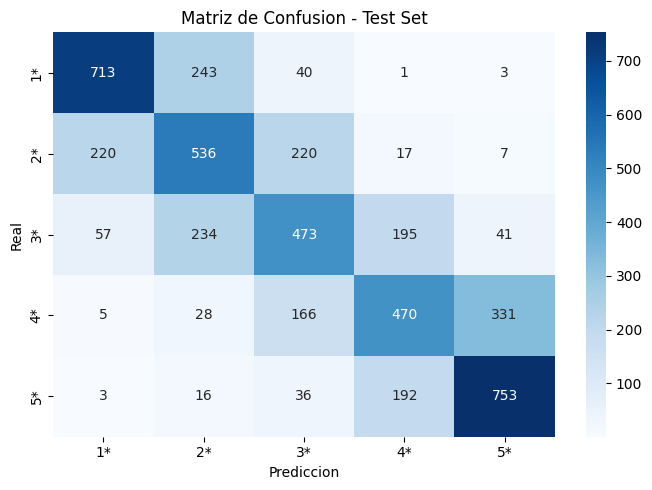

Figura guardada: confusion_matrix.png


In [22]:
# Obtener predicciones sobre el test set
preds_output = trainer_eval.predict(datos_tokenizados['test'])
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

# Reporte por clase
print('CLASSIFICATION REPORT (clases: 1 a 5 estrellas)')
print('='*55)
print(classification_report(
    y_true, y_pred,
    target_names=['1 estrella', '2 estrellas', '3 estrellas', '4 estrellas', '5 estrellas']
))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=['1*','2*','3*','4*','5*'],
    yticklabels=['1*','2*','3*','4*','5*'],
    cmap='Blues'
)
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.title('Matriz de Confusion - Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Figura guardada: confusion_matrix.png')


## 13. Curvas de entrenamiento

Una brecha pequeña entre `Train Loss` y `Val Loss` indica que el overfitting está controlado. La línea roja marca la época del mejor modelo seleccionado por EarlyStopping.

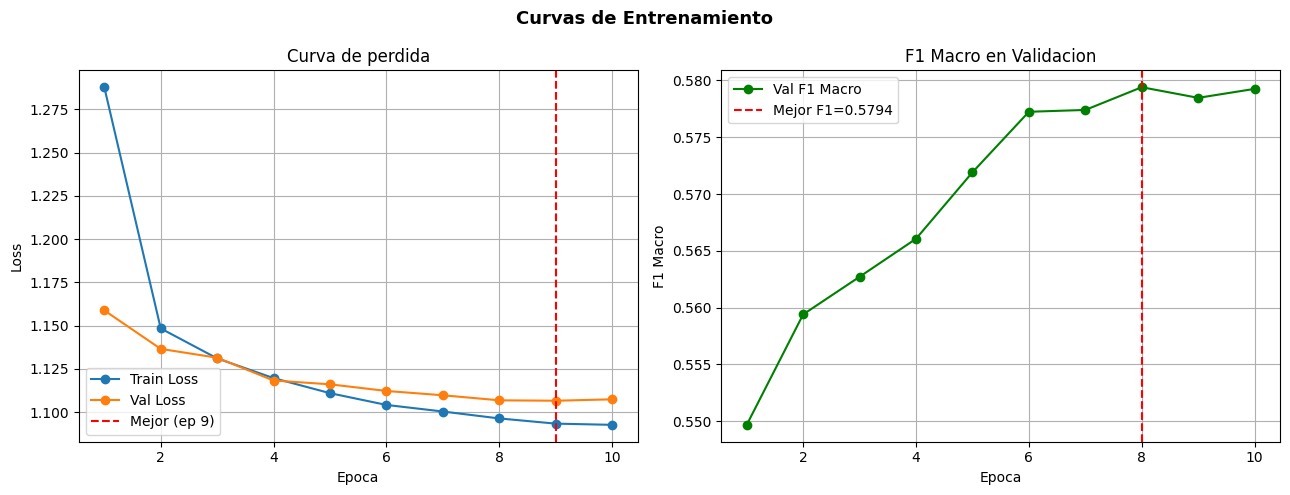

Figura guardada: training_curves.png


In [23]:
logs = pd.DataFrame(trainer.state.log_history)

train_logs = logs[logs['loss'].notna()].copy()
eval_logs  = logs[logs['eval_loss'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Loss ---
axes[0].plot(train_logs['epoch'], train_logs['loss'], 'o-', label='Train Loss')
axes[0].plot(eval_logs['epoch'],  eval_logs['eval_loss'], 'o-', label='Val Loss')
best_ep = eval_logs.loc[eval_logs['eval_loss'].idxmin(), 'epoch']
axes[0].axvline(best_ep, color='red', linestyle='--', label=f'Mejor (ep {best_ep:.0f})')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de perdida')
axes[0].legend()
axes[0].grid(True)

# --- F1 Macro ---
if 'eval_f1_macro' in eval_logs.columns:
    axes[1].plot(eval_logs['epoch'], eval_logs['eval_f1_macro'],
                 'o-', color='green', label='Val F1 Macro')
    best_f1_idx = eval_logs['eval_f1_macro'].idxmax()
    best_f1_ep  = eval_logs.loc[best_f1_idx, 'epoch']
    best_f1_val = eval_logs.loc[best_f1_idx, 'eval_f1_macro']
    axes[1].axvline(best_f1_ep, color='red', linestyle='--',
                    label=f'Mejor F1={best_f1_val:.4f}')
    axes[1].set_xlabel('Epoca')
    axes[1].set_ylabel('F1 Macro')
    axes[1].set_title('F1 Macro en Validacion')
    axes[1].legend()
    axes[1].grid(True)

plt.suptitle('Curvas de Entrenamiento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Figura guardada: training_curves.png')


## 14. Análisis de errores

En la clasificación de 5 estrellas, la mayoría de los errores suelen ser **adyacentes** (confundir 3★ con 4★, o 2★ con 3★). Los errores graves (|pred - real| >= 2) son más informativos para entender las limitaciones del modelo.

In [24]:
df_test = dataset['test'].to_pandas()
df_test['pred'] = y_pred
df_test['real'] = y_true
df_test['error'] = df_test['pred'] != df_test['real']
df_test['distancia'] = abs(df_test['pred'] - df_test['real'])

total_err = df_test['error'].sum()
total = len(df_test)
print(f'Errores totales: {total_err} / {total} ({total_err/total*100:.1f}%)')

print('\nDistribucion de errores por distancia:')
dist = df_test[df_test['error']]['distancia'].value_counts().sort_index()
for d, n in dist.items():
    print(f'  |pred - real| = {d}: {n} casos ({n/total_err*100:.1f}% de los errores)')

print('\nEjemplos con error grave (|pred - real| >= 2):')
graves = df_test[df_test['distancia'] >= 2][['text', 'real', 'pred']].head(6)
graves['real'] = graves['real'].apply(lambda x: f'{x+1} estrellas')
graves['pred'] = graves['pred'].apply(lambda x: f'{x+1} estrellas')
graves


Errores totales: 2055 / 5000 (41.1%)

Distribucion de errores por distancia:
  |pred - real| = 1: 1801 casos (87.6% de los errores)
  |pred - real| = 2: 219 casos (10.7% de los errores)
  |pred - real| = 3: 29 casos (1.4% de los errores)
  |pred - real| = 4: 6 casos (0.3% de los errores)

Ejemplos con error grave (|pred - real| >= 2):


,text,real,pred
11,"No enviaron la cantidad prometida, llegó uno m...",1 estrellas,3 estrellas
14,No me gusta nada de nada....pero es lo que qui...,1 estrellas,3 estrellas
46,"Son tan cortos que apenas puedes enchufarlos, ...",1 estrellas,3 estrellas
162,"Aunque parece buen idea, no es más fácil que l...",1 estrellas,3 estrellas
173,La funda perfecta de el cristal templado se de...,1 estrellas,3 estrellas
182,Producto con evidentes señales de uso,1 estrellas,3 estrellas


In [25]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true, y_pred)
print(f"MAE: {mae:.4f}")

MAE: 0.4700
